# Topic modeling and keyword sensitivity — Exorde sample

This notebook is **separate** from `analysis_events.ipynb` (baseline tables and plots).

1. **NMF topics** (TF–IDF) within each baseline keyword event — exploratory sub-themes.
2. **Document-level topic assignments** (`doc_topics` DataFrame) for platform / sentiment plots.
3. **Sensitivity run**: `EVENTS_SENSITIVITY` in `exorde_analysis.py` extends baseline keywords; `run_pipeline(df, events=EVENTS_SENSITIVITY)` repeats aggregations under the refined definition. Edit `EVENTS_SENSITIVITY` after you review top terms here — the bundled lists are a starting point, not ground truth.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from exorde_analysis import EVENTS, EVENTS_SENSITIVITY, get_platform, run_pipeline
from exorde_topics import run_nmf_topics, run_nmf_topics_all_events, topic_time_counts, topic_time_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
CSV_PATH = Path("data/stratified_dates_platforms_1M.csv")

## 1. NMF topic summaries (baseline `EVENTS`)

Random subsample per event (`max_docs`). Increase if you need more stable terms.

In [2]:
df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
df["platform"] = df["url"].map(get_platform) if "url" in df.columns else "missing"

topic_reports = run_nmf_topics_all_events(
    df, max_docs=20_000, n_topics=10, random_state=RANDOM_STATE
)

for ev, r in topic_reports.items():
    print("=" * 72)
    print(r.get("label", ev))
    if not r.get("ok"):
        print("  skipped:", r.get("reason"))
        continue
    print(f"  n_posts={r['n_posts']}, n_topics_fitted={r['n_topics']}")
    for t in r["topics"][:10]:
        terms = ", ".join(t["top_terms"][:10])
        print(f"  [{t['id']}] p={t['prevalence']:.3f}  {terms}")

US politics (post–US election, Dec 2024 week)
  n_posts=20000, n_topics_fitted=10
  [1] p=0.289  trump, trump trump, people, brics, maga, fbi, president trump, america, won, voted
  [3] p=0.128  party, democratic, democrat, democrats, democratic party, republican, people, republicans, democrat party, gop
  [8] p=0.121  election, vote, results, win, elections, won, people, election election, presidential, day
  [2] p=0.119  president, president president, president trump, president biden, elect, states, united, president elect, united states, south
  [0] p=0.117  biden, hunter, pardon, hunter biden, son, pardoned, pardons, biden pardon, family, crime
  [7] p=0.088  la, que, el, en, los, se, es, del, presidente, por
  [5] p=0.043  joe, joe biden, biden, biden joe, joe joe, president joe, son, biden biden, liar, good
  [6] p=0.037  harris, kamala, kamala harris, harris kamala, campaign, money, kamala kamala, harris harris, lost, debt
  [4] p=0.030  house, white, white house, house white, 

## 2. Document-level topics + metadata (`doc_topics`)

For **each** baseline event in `EVENTS` — dominant topic per post (argmax on NMF weights), joined with platform and sentiment. The cells below loop over all events; use the same pattern for cross-tabs, bar charts, or mean sentiment by `topic_id`.

In [3]:
doc_by_event: dict[str, pd.DataFrame] = {}
for ev_demo in EVENTS:
    r = run_nmf_topics(
        df,
        ev_demo,
        max_docs=15_000,
        n_topics=8,
        random_state=RANDOM_STATE,
        return_doc_topics=True,
    )
    if not r.get("ok"):
        print(f"{ev_demo}: skipped — {r.get('reason')}")
        continue
    doc_by_event[ev_demo] = r["doc_topics"]
    print(f"\n=== {EVENTS[ev_demo]['label']} ({ev_demo}) ===")
    display(doc_by_event[ev_demo].head())


=== US politics (post–US election, Dec 2024 week) (us_politics) ===


,event_key,event_label,topic_id,topic_weight,topic_entropy,platform,date,date_str,sentiment,language,main_emotion,primary_theme
source_index,,,,,,,,,,,,
603849,us_politics,"US politics (post–US election, Dec 2024 week)",3,0.017058,1.673630e+00,x.com,2024-12-03 03:32:43,2024-12-03,0.00,en,neutral,Politics
334307,us_politics,"US politics (post–US election, Dec 2024 week)",1,0.040112,8.841485e-01,x.com,2024-12-07 03:01:17,2024-12-07,-0.09,en,annoyance,Economy
749389,us_politics,"US politics (post–US election, Dec 2024 week)",1,0.023472,8.146011e-01,x.com,2024-12-04 21:52:29,2024-12-04,-0.03,en,neutral,People
566883,us_politics,"US politics (post–US election, Dec 2024 week)",3,0.091342,5.219528e-01,bsky.app,2024-12-02 02:51:14,2024-12-02,-0.18,en,neutral,Politics
357197,us_politics,"US politics (post–US election, Dec 2024 week)",3,0.117165,7.549517e-15,x.com,2024-12-07 02:54:11,2024-12-07,-0.48,en,neutral,Politics



=== Syria conflict (rebel offensive, Dec 2024) (syria) ===


,event_key,event_label,topic_id,topic_weight,topic_entropy,platform,date,date_str,sentiment,language,main_emotion,primary_theme
source_index,,,,,,,,,,,,
434,syria,"Syria conflict (rebel offensive, Dec 2024)",0,0.036273,0.931754,x.com,2024-12-01 10:08:33,2024-12-01,-0.26,en,neutral,Politics
439,syria,"Syria conflict (rebel offensive, Dec 2024)",5,0.113154,1.163524,x.com,2024-12-01 11:03:08,2024-12-01,-0.51,it,neutral,Politics
559,syria,"Syria conflict (rebel offensive, Dec 2024)",4,0.079520,0.948001,x.com,2024-12-01 09:00:08,2024-12-01,-0.24,en,neutral,Politics
563,syria,"Syria conflict (rebel offensive, Dec 2024)",3,0.015362,1.326703,x.com,2024-12-01 09:31:22,2024-12-01,-0.19,pt,neutral,Politics
659,syria,"Syria conflict (rebel offensive, Dec 2024)",6,0.017190,1.079989,x.com,2024-12-01 10:13:57,2024-12-01,0.30,en,neutral,Sports



=== Romania (election annulment / political crisis) (romania) ===


,event_key,event_label,topic_id,topic_weight,topic_entropy,platform,date,date_str,sentiment,language,main_emotion,primary_theme
source_index,,,,,,,,,,,,
745,romania,Romania (election annulment / political crisis),0,0.067947,1.442564,x.com,2024-12-01 10:44:31,2024-12-01,-0.47,en,neutral,Politics
828,romania,Romania (election annulment / political crisis),6,0.171144,0.769946,x.com,2024-12-01 10:29:36,2024-12-01,-0.01,ro,neutral,Entertainment
1918,romania,Romania (election annulment / political crisis),0,0.000000,-0.000000,x.com,2024-12-01 10:29:53,2024-12-01,0.24,en,neutral,Entertainment
4825,romania,Romania (election annulment / political crisis),6,0.083117,0.956644,x.com,2024-12-01 10:07:30,2024-12-01,-0.42,ro,neutral,Politics
8287,romania,Romania (election annulment / political crisis),1,0.304066,0.530181,x.com,2024-12-01 10:46:14,2024-12-01,0.81,ro,excitement,People



=== Sri Lanka / NPP (sri_lanka) ===


,event_key,event_label,topic_id,topic_weight,topic_entropy,platform,date,date_str,sentiment,language,main_emotion,primary_theme
source_index,,,,,,,,,,,,
254,sri_lanka,Sri Lanka / NPP,0,0.029617,1.310382,x.com,2024-12-01 09:06:09,2024-12-01,0.80,en,pride,Politics
955,sri_lanka,Sri Lanka / NPP,5,0.053820,1.057219,x.com,2024-12-01 10:42:37,2024-12-01,-0.09,de,neutral,Politics
2431,sri_lanka,Sri Lanka / NPP,7,0.018269,1.128272,x.com,2024-12-01 10:24:24,2024-12-01,-0.68,ja,neutral,Science
2712,sri_lanka,Sri Lanka / NPP,0,0.067102,0.651738,x.com,2024-12-01 10:50:31,2024-12-01,-0.60,pt,neutral,Politics
5110,sri_lanka,Sri Lanka / NPP,3,0.026570,1.434957,x.com,2024-12-01 10:21:52,2024-12-01,0.20,ja,neutral,Politics



=== Gaza / Israel (gaza_israel) ===


,event_key,event_label,topic_id,topic_weight,topic_entropy,platform,date,date_str,sentiment,language,main_emotion,primary_theme
source_index,,,,,,,,,,,,
70,gaza_israel,Gaza / Israel,7,0.373144,3.980587e-02,x.com,2024-12-01 08:40:21,2024-12-01,0.12,en,neutral,Entertainment
74,gaza_israel,Gaza / Israel,2,0.251564,2.997602e-15,x.com,2024-12-01 09:04:54,2024-12-01,0.01,en,approval,Politics
114,gaza_israel,Gaza / Israel,5,0.031673,9.205710e-01,x.com,2024-12-01 10:23:21,2024-12-01,-0.05,en,curiosity,Politics
325,gaza_israel,Gaza / Israel,0,0.029509,8.664427e-01,x.com,2024-12-01 10:20:42,2024-12-01,-0.45,en,neutral,Politics
331,gaza_israel,Gaza / Israel,7,0.441638,1.221245e-15,x.com,2024-12-01 10:24:24,2024-12-01,0.08,en,neutral,Entertainment


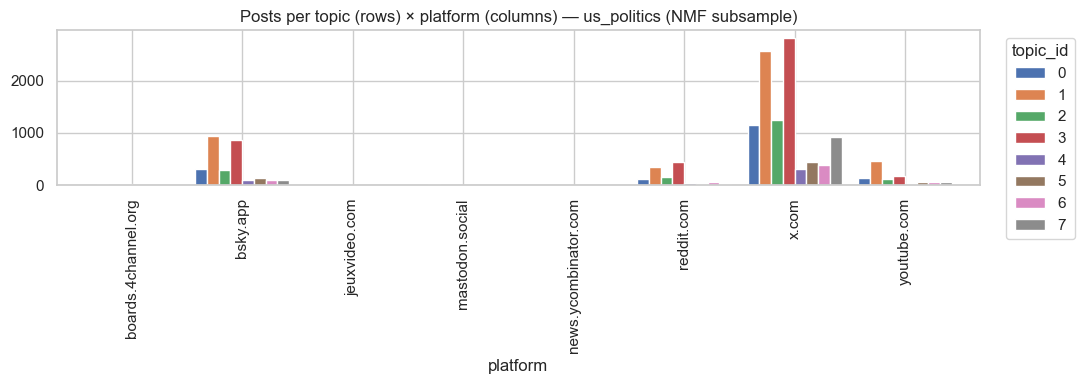

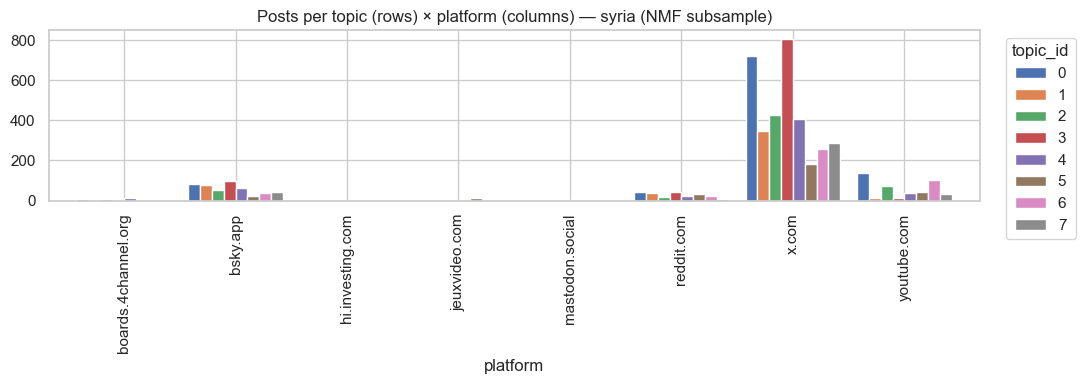

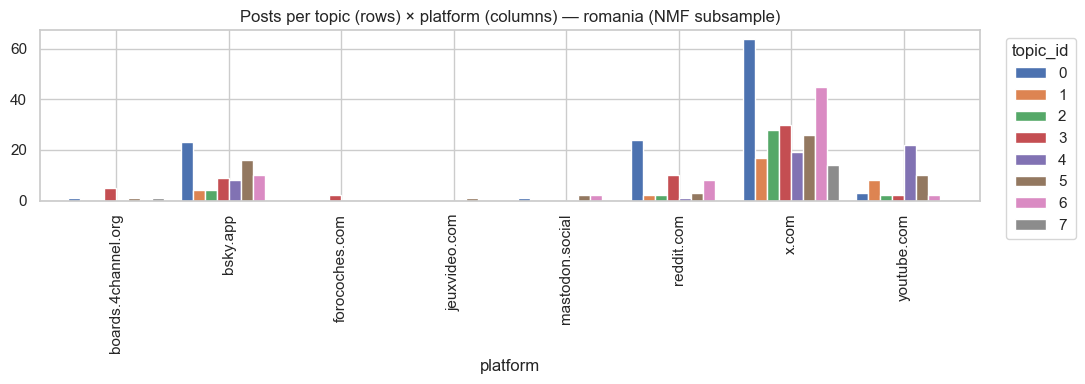

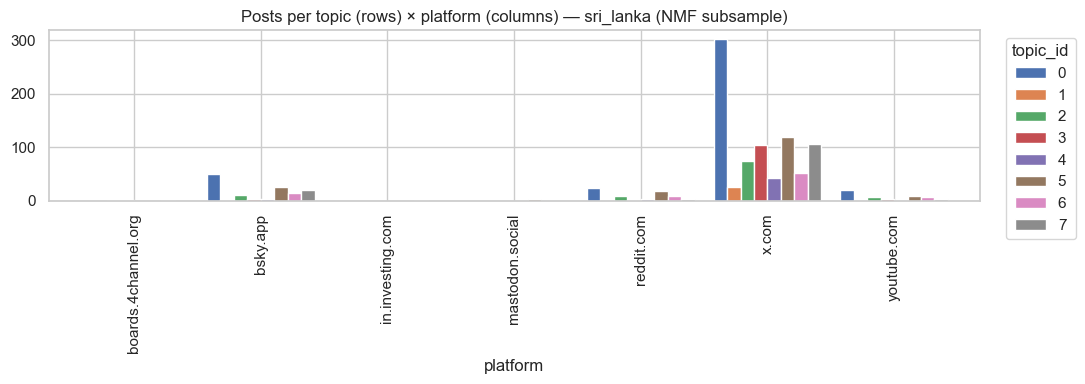

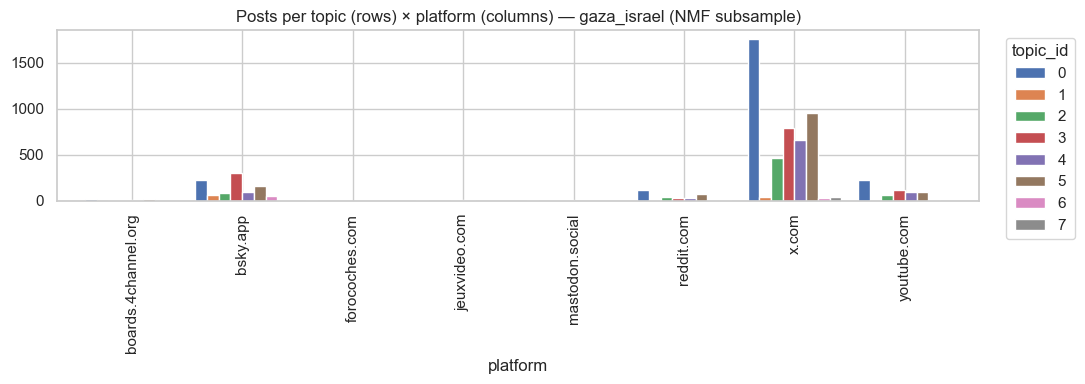

In [4]:
# Topic prevalence by platform (counts) — one figure per event
for ev_demo, doc in doc_by_event.items():
    ct = (
        doc.groupby(["platform", "topic_id"], observed=False)
        .size()
        .reset_index(name="n")
    )
    top_plat = doc["platform"].value_counts().head(8).index.tolist()
    ct = ct[ct["platform"].isin(top_plat)]

    pivot = ct.pivot(index="topic_id", columns="platform", values="n").fillna(0)
    ax = pivot.T.plot(kind="bar", figsize=(11, 4), width=0.85)
    ax.set_title(
        f"Posts per topic (rows) × platform (columns) — {ev_demo} (NMF subsample)"
    )
    ax.set_xlabel("platform")
    ax.legend(title="topic_id", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [5]:
# Mean sentiment by dominant topic (where sentiment is present)
for ev_demo, doc in doc_by_event.items():
    print(
        f"\n=== {EVENTS[ev_demo]['label']} ({ev_demo}) — mean sentiment by topic_id ==="
    )
    if doc["sentiment"].notna().any():
        sub = doc.dropna(subset=["sentiment"])
        agg = sub.groupby("topic_id", observed=False)["sentiment"].agg(["mean", "count"])
        display(agg)
    else:
        print("No sentiment column or all NaN")


=== US politics (post–US election, Dec 2024 week) (us_politics) — mean sentiment by topic_id ===


,mean,count
topic_id,,
0,-0.232572,1711
1,-0.187123,4353
2,-0.107133,1807
3,-0.177617,4321
4,-0.182389,452
5,-0.213358,673
6,-0.131477,596
7,-0.114554,1087



=== Syria conflict (rebel offensive, Dec 2024) (syria) — mean sentiment by topic_id ===


,mean,count
topic_id,,
0,-0.195729,995
1,-0.006072,485
2,-0.240156,577
3,-0.082899,978
4,-0.277234,546
5,-0.280237,295
6,-0.278310,420
7,-0.179948,381



=== Romania (election annulment / political crisis) (romania) — mean sentiment by topic_id ===


,mean,count
topic_id,,
0,-0.085948,116
1,0.558065,31
2,-0.115278,36
3,-0.041207,58
4,-0.136275,51
5,-0.351017,59
6,-0.150000,67
7,0.010000,15



=== Sri Lanka / NPP (sri_lanka) — mean sentiment by topic_id ===


,mean,count
topic_id,,
0,-0.175856,397
1,0.015556,27
2,0.071100,100
3,-0.082909,110
4,-0.009574,47
5,-0.080117,171
6,-0.206807,83
7,-0.237077,130



=== Gaza / Israel (gaza_israel) — mean sentiment by topic_id ===


,mean,count
topic_id,,
0,-0.188883,2349
1,-0.210000,102
2,-0.113978,651
3,-0.294964,1239
4,-0.302879,870
5,-0.275813,1286
6,0.116184,76
7,0.307143,42


## 3. Topic spread over time

These plots use the document-level NMF assignment table (`doc_topics`) and bucket each assigned topic by date. Use `TOPIC_TIME_FREQ = "h"` for hourly buckets when the event has enough timestamp coverage.


=== US politics (post–US election, Dec 2024 week) (us_politics) topic x time ===


,time_bucket,topic_id,n,total_in_time,total_in_topic,share_within_time,share_within_topic
0,2024-12-01 00:00:00+00:00,0,37,1502,1711,0.024634,0.021625
1,2024-12-01 00:00:00+00:00,1,482,1502,4353,0.320905,0.110728
2,2024-12-01 00:00:00+00:00,2,193,1502,1807,0.128495,0.106807
3,2024-12-01 00:00:00+00:00,3,460,1502,4321,0.306258,0.106457
4,2024-12-01 00:00:00+00:00,4,24,1502,452,0.015979,0.053097
5,2024-12-01 00:00:00+00:00,5,28,1502,673,0.018642,0.041605
6,2024-12-01 00:00:00+00:00,6,88,1502,596,0.058589,0.147651
7,2024-12-01 00:00:00+00:00,7,190,1502,1087,0.126498,0.174793
8,2024-12-02 00:00:00+00:00,0,764,3602,1711,0.212104,0.446523
9,2024-12-02 00:00:00+00:00,1,997,3602,4353,0.276791,0.229037


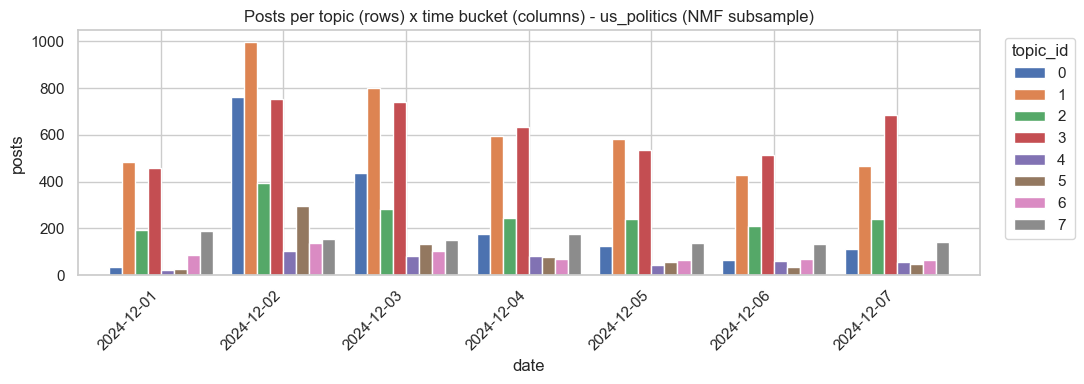


=== Syria conflict (rebel offensive, Dec 2024) (syria) topic x time ===


,time_bucket,topic_id,n,total_in_time,total_in_topic,share_within_time,share_within_topic
0,2024-12-01 00:00:00+00:00,0,241,1084,995,0.222325,0.242211
1,2024-12-01 00:00:00+00:00,1,67,1084,485,0.061808,0.138144
2,2024-12-01 00:00:00+00:00,2,163,1084,577,0.150369,0.282496
3,2024-12-01 00:00:00+00:00,3,120,1084,978,0.110701,0.122699
4,2024-12-01 00:00:00+00:00,4,164,1084,546,0.151292,0.300366
5,2024-12-01 00:00:00+00:00,5,83,1084,295,0.076568,0.281356
6,2024-12-01 00:00:00+00:00,6,128,1084,420,0.118081,0.304762
7,2024-12-01 00:00:00+00:00,7,118,1084,381,0.108856,0.309711
8,2024-12-02 00:00:00+00:00,0,136,718,995,0.189415,0.136683
9,2024-12-02 00:00:00+00:00,1,144,718,485,0.200557,0.296907


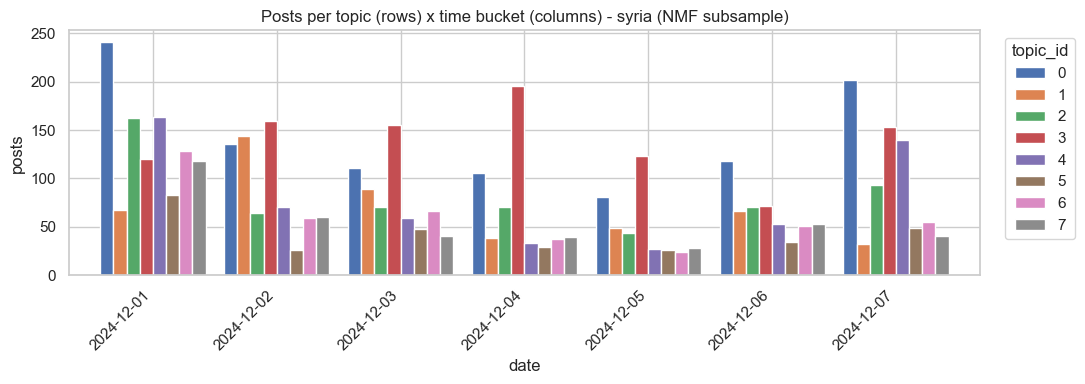


=== Romania (election annulment / political crisis) (romania) topic x time ===


,time_bucket,topic_id,n,total_in_time,total_in_topic,share_within_time,share_within_topic
0,2024-12-01 00:00:00+00:00,0,22,96,116,0.229167,0.189655
1,2024-12-01 00:00:00+00:00,1,23,96,31,0.239583,0.741935
2,2024-12-01 00:00:00+00:00,2,7,96,36,0.072917,0.194444
3,2024-12-01 00:00:00+00:00,3,12,96,58,0.125000,0.206897
4,2024-12-01 00:00:00+00:00,4,3,96,51,0.031250,0.058824
5,2024-12-01 00:00:00+00:00,5,4,96,59,0.041667,0.067797
6,2024-12-01 00:00:00+00:00,6,25,96,67,0.260417,0.373134
7,2024-12-02 00:00:00+00:00,0,12,28,116,0.428571,0.103448
8,2024-12-02 00:00:00+00:00,1,1,28,31,0.035714,0.032258
9,2024-12-02 00:00:00+00:00,2,1,28,36,0.035714,0.027778


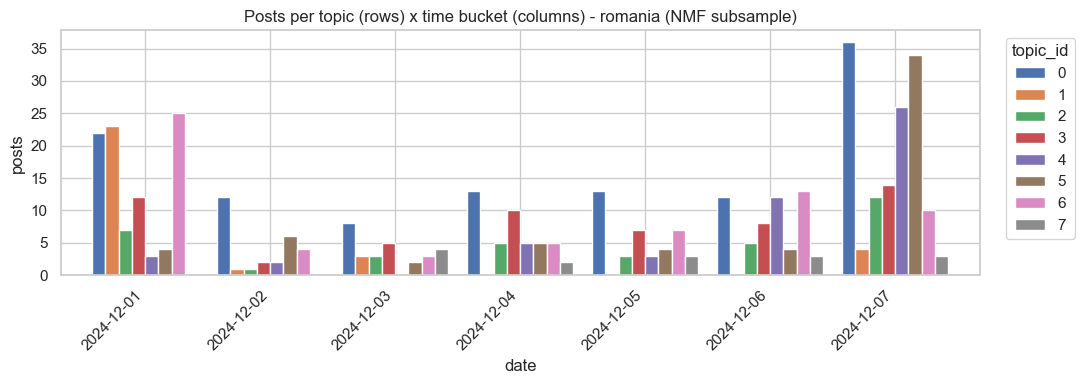


=== Sri Lanka / NPP (sri_lanka) topic x time ===


,time_bucket,topic_id,n,total_in_time,total_in_topic,share_within_time,share_within_topic
0,2024-12-01 00:00:00+00:00,0,79,218,397,0.362385,0.198992
1,2024-12-01 00:00:00+00:00,1,1,218,27,0.004587,0.037037
2,2024-12-01 00:00:00+00:00,2,24,218,100,0.110092,0.240000
3,2024-12-01 00:00:00+00:00,3,28,218,110,0.128440,0.254545
4,2024-12-01 00:00:00+00:00,4,4,218,47,0.018349,0.085106
5,2024-12-01 00:00:00+00:00,5,42,218,171,0.192661,0.245614
6,2024-12-01 00:00:00+00:00,6,8,218,83,0.036697,0.096386
7,2024-12-01 00:00:00+00:00,7,32,218,130,0.146789,0.246154
8,2024-12-02 00:00:00+00:00,0,42,98,397,0.428571,0.105793
9,2024-12-02 00:00:00+00:00,2,11,98,100,0.112245,0.110000


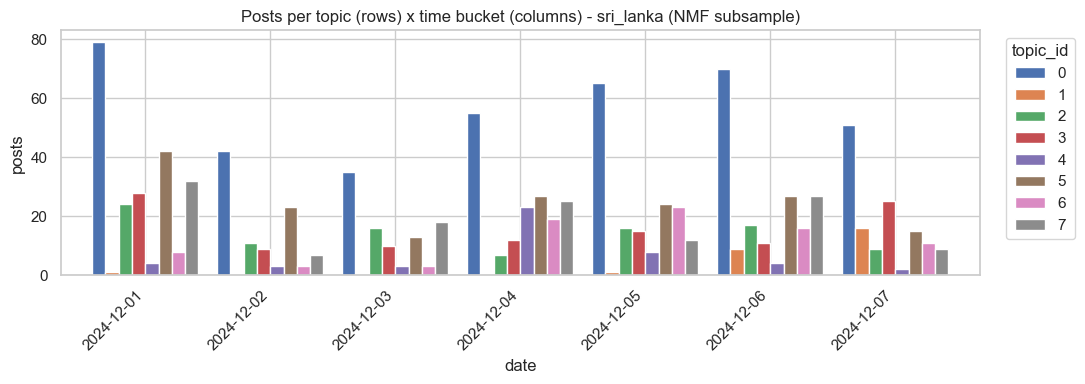


=== Gaza / Israel (gaza_israel) topic x time ===


,time_bucket,topic_id,n,total_in_time,total_in_topic,share_within_time,share_within_topic
0,2024-12-01 00:00:00+00:00,0,453,1248,2349,0.362981,0.192848
1,2024-12-01 00:00:00+00:00,1,8,1248,102,0.006410,0.078431
2,2024-12-01 00:00:00+00:00,2,150,1248,651,0.120192,0.230415
3,2024-12-01 00:00:00+00:00,3,222,1248,1239,0.177885,0.179177
4,2024-12-01 00:00:00+00:00,4,152,1248,870,0.121795,0.174713
5,2024-12-01 00:00:00+00:00,5,225,1248,1286,0.180288,0.174961
6,2024-12-01 00:00:00+00:00,6,7,1248,76,0.005609,0.092105
7,2024-12-01 00:00:00+00:00,7,31,1248,42,0.024840,0.738095
8,2024-12-02 00:00:00+00:00,0,323,827,2349,0.390568,0.137505
9,2024-12-02 00:00:00+00:00,1,6,827,102,0.007255,0.058824


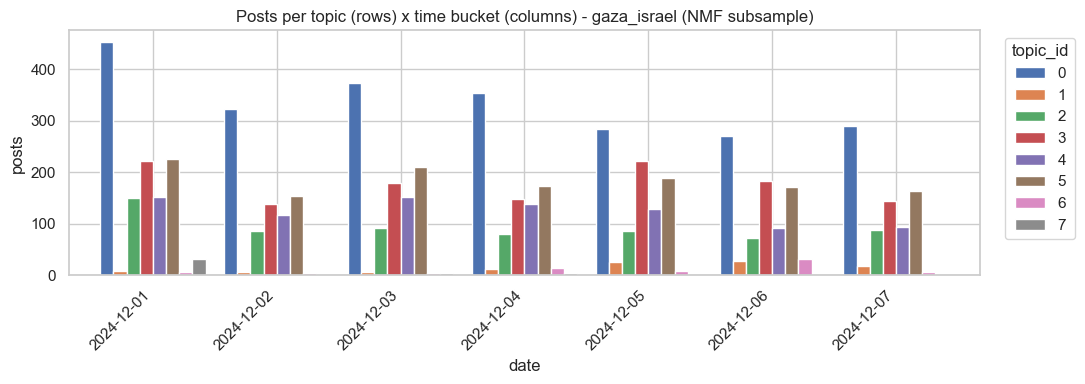

In [6]:
# Topic prevalence by day/time (counts) - same grouped-bar style as topic x platform
TOPIC_TIME_FREQ = "D"  # "D" = daily; use "h" for hourly buckets

for ev_demo, doc in doc_by_event.items():
    matrix = topic_time_matrix(doc, freq=TOPIC_TIME_FREQ, value="n")
    if matrix.empty:
        print(f"{ev_demo}: no topic/time rows to plot")
        continue

    counts = topic_time_counts(doc, freq=TOPIC_TIME_FREQ)
    print(f"\n=== {EVENTS[ev_demo]['label']} ({ev_demo}) topic x time ===")
    display(counts.head(12))

    plot_df = matrix.copy()
    plot_df.index = [str(x)[:10] if TOPIC_TIME_FREQ == "D" else str(x)[:16] for x in plot_df.index]
    ax = plot_df.plot(kind="bar", figsize=(11, 4), width=0.85)
    ax.set_title(f"Posts per topic (rows) x time bucket (columns) - {ev_demo} (NMF subsample)")
    ax.set_xlabel("date" if TOPIC_TIME_FREQ == "D" else "time bucket")
    ax.set_ylabel("posts")
    ax.legend(title="topic_id", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45 if TOPIC_TIME_FREQ == "D" else 75, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Keyword sensitivity — `EVENTS_SENSITIVITY` vs baseline `EVENTS`

- **Baseline** (`EVENTS`): primary definition in the report.
- **Sensitivity v2** (`EVENTS_SENSITIVITY`): same event keys, **extra** substrings (edit in `exorde_analysis.py` after reviewing NMF terms above — avoid overly generic words).
- `run_pipeline` returns `events_definition`: `"baseline"` or `"custom"`.

In [7]:
out_base = run_pipeline(df)
out_sens = run_pipeline(df, events=EVENTS_SENSITIVITY)

cmp = pd.DataFrame(
    {
        "event": list(EVENTS.keys()),
        "n_baseline": [out_base["event_n"][e] for e in EVENTS],
        "pct_baseline": [out_base["event_pct"][e] for e in EVENTS],
        "n_sensitivity": [out_sens["event_n"][e] for e in EVENTS],
        "pct_sensitivity": [out_sens["event_pct"][e] for e in EVENTS],
    }
)
cmp["delta_n"] = cmp["n_sensitivity"] - cmp["n_baseline"]
cmp["delta_pct_points"] = cmp["pct_sensitivity"] - cmp["pct_baseline"]
display(cmp)
print("baseline:", out_base.get("events_definition"))
print("sensitivity:", out_sens.get("events_definition"))

,event,n_baseline,pct_baseline,n_sensitivity,pct_sensitivity,delta_n,delta_pct_points
0,us_politics,33188,3.318803,39579,3.957904,6391,0.639101
1,syria,4681,0.468100,19106,1.910602,14425,1.442501
2,romania,433,0.043300,8719,0.871901,8286,0.828601
3,sri_lanka,1065,0.106500,19660,1.966002,18595,1.859502
4,gaza_israel,6623,0.662301,7763,0.776301,1140,0.114000


baseline: baseline
sensitivity: custom


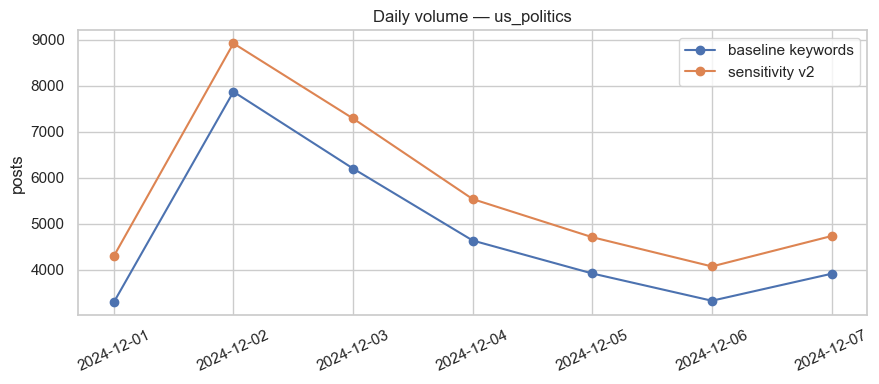

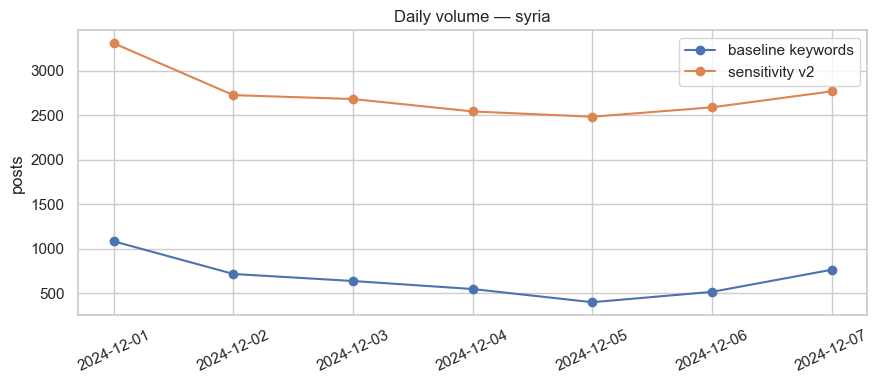

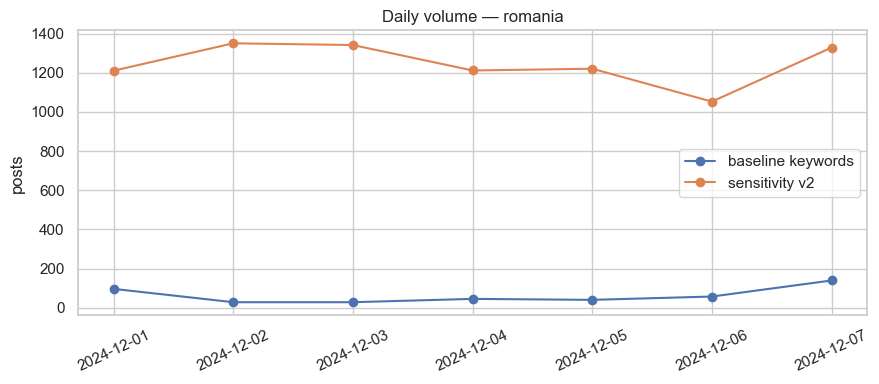

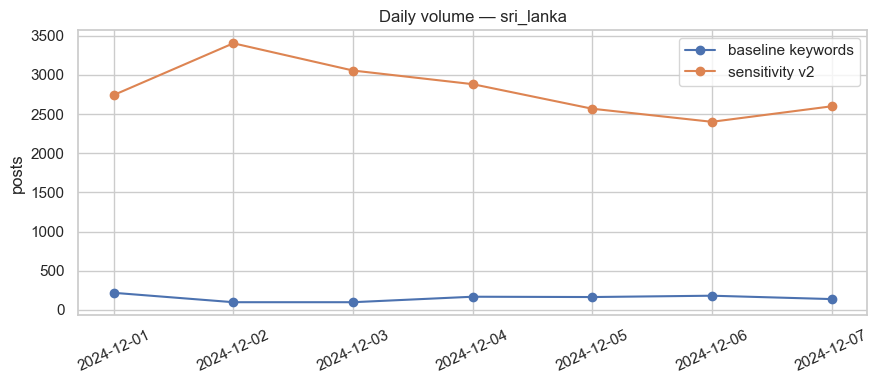

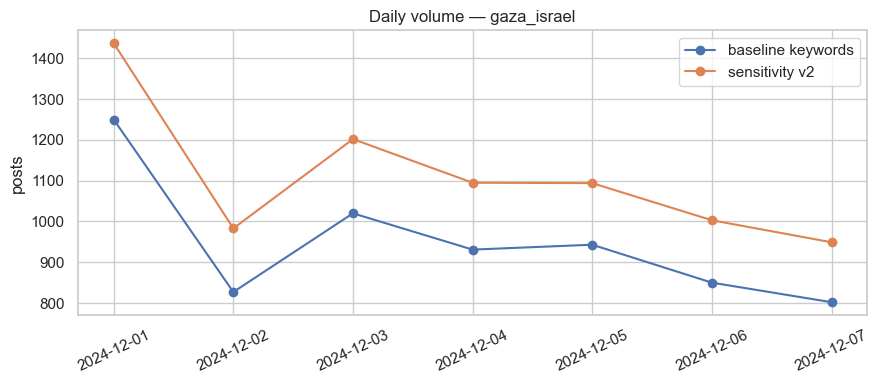

In [8]:
# Daily time series under baseline vs sensitivity — one plot per event
from exorde_analysis import daily_event_df

for ev in EVENTS:
    d0 = daily_event_df(out_base["ed_daily"], ev)
    d1 = daily_event_df(out_sens["ed_daily"], ev)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(d0["date"], d0["n"], label="baseline keywords", marker="o")
    ax.plot(d1["date"], d1["n"], label="sensitivity v2", marker="o")
    ax.set_title(f"Daily volume — {ev}")
    ax.set_ylabel("posts")
    ax.legend()
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()